<a href="https://colab.research.google.com/github/vishalraine123-rgb/CN7030-2526-T3-Machine-Learning-on-Big-Data-OC-/blob/main/week4_titanic_synthetic_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#raw_data = spark.read.format("csv").option("header","true").option("inferSchema", "true").load(r".\\diabetes.csv")
dataset = spark.read.csv('titanic_synthetic_data.csv',inferSchema=True, header =True)

In [6]:
dataset.show(5)

+------+---+-----+-----+------------------+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+------------------+---+--------+----------+----------+
|     3| 42|    6|    7|397.00178367782024|  0|       0|         0|         1|
|     1| 52|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3| 25|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3| 32|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1| 40|    0|    5|17.718838497771657|  0|       0|         0|         0|
+------+---+-----+-----+------------------+---+--------+----------+----------+
only showing top 5 rows


In [7]:
# what are the columns in this dataset
dataset.columns

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

In [13]:
dataset.describe().select("Summary","Pclass","Age","SibSp","Parch","Fare").show()


+-------+------------------+------------------+------------------+------------------+------------------+
|Summary|            Pclass|               Age|             SibSp|             Parch|              Fare|
+-------+------------------+------------------+------------------+------------------+------------------+
|  count|           1000000|           1000000|           1000000|           1000000|           1000000|
|   mean|          1.999411|         39.517847|          4.500906|          4.497493| 254.9829083944402|
| stddev|0.8168263709530482|23.092708389398037|2.8714427426552285|2.8728101169393594|141.53963219142216|
|    min|                 1|                 0|                 0|                 0|10.000191449724019|
|    max|                 3|                79|                 9|                 9| 499.9999338139367|
+-------+------------------+------------------+------------------+------------------+------------------+



In [12]:
dataset.describe().select("Summary","Embarked_Q","Embarked_S").show()


+-------+-------------------+------------------+
|Summary|         Embarked_Q|        Embarked_S|
+-------+-------------------+------------------+
|  count|            1000000|           1000000|
|   mean|           0.332717|          0.333661|
| stddev|0.47118639616145436|0.4715204761307361|
|    min|                  0|                 0|
|    max|                  1|                 1|
+-------+-------------------+------------------+



In [14]:
dataset.describe().select("Summary","Age","Sex","Survived").show()

+-------+------------------+------------------+------------------+
|Summary|               Age|               Sex|          Survived|
+-------+------------------+------------------+------------------+
|  count|           1000000|           1000000|           1000000|
|   mean|         39.517847|           0.50082|           0.49987|
| stddev|23.092708389398037|0.4999995775993916|0.5000002331001768|
|    min|                 0|                 0|                 0|
|    max|                79|                 1|                 1|
+-------+------------------+------------------+------------------+



In [16]:
from pyspark.sql.functions import col,isnan, when, count
dataset.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in dataset.columns]
   ).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



In [10]:
print(dataset.head())
dataset.printSchema()

Row(Pclass=3, Age=42, SibSp=6, Parch=7, Fare=397.00178367782024, Sex=0, Survived=0, Embarked_Q=0, Embarked_S=1)
root
 |-- Pclass: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Sex: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Embarked_Q: integer (nullable = true)
 |-- Embarked_S: integer (nullable = true)




Class Distribution:
Survived
0    500130
1    499870
Name: count, dtype: int64


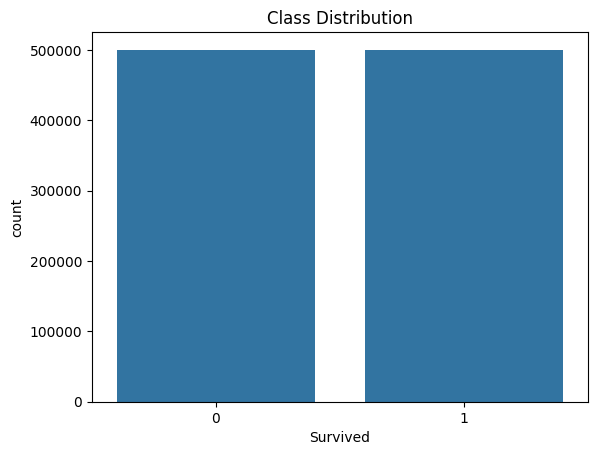


Percentage:
Survived
0    50.013
1    49.987
Name: proportion, dtype: float64


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = dataset.toPandas()

print("\nClass Distribution:")
print(df['Survived'].value_counts())

sns.countplot(x='Survived', data=df)
plt.title("Class Distribution")
plt.show()

# Percentage distribution
print("\nPercentage:")
print(df['Survived'].value_counts(normalize=True)*100)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
#Train, test split
train, test = dataset.randomSplit([0.8, 0.2], seed=12345)

In [28]:
#imbalance in the dataset, observe the use of Where
dataset_size=float(train.select("Survived").count())
numPositives=train.select("Survived").where('Survived == 1').count()
per_ones=(float(numPositives)/float(dataset_size))*100
numNegatives=float(dataset_size-numPositives)
print('The number of ones are {}'.format(numPositives))
print('Percentage of ones are {}'.format(per_ones))

The number of ones are 399849
Percentage of ones are 49.965885404951486


In [29]:
BalancingRatio= numNegatives/dataset_size
print('BalancingRatio = {}'.format(BalancingRatio))

BalancingRatio = 0.5003411459504851


In [31]:
# balance
train=train.withColumn("classWeights", when(train.Survived == 1,BalancingRatio).otherwise(1-BalancingRatio))
train.select("classWeights").show(5)

+-------------------+
|       classWeights|
+-------------------+
|0.49965885404951493|
|0.49965885404951493|
| 0.5003411459504851|
| 0.5003411459504851|
| 0.5003411459504851|
+-------------------+
only showing top 5 rows


In [33]:
#Building a classification model using Logistic Regression (LR)
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler

# Define feature columns
feature_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked_Q', 'Embarked_S']

# Assemble features into a single vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Transform the training and testing datasets
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

lr = LogisticRegression(labelCol="Survived", featuresCol="features", weightCol="classWeights", maxIter=10)
model=lr.fit(train_assembled)
predict_train=model.transform(train_assembled)
predict_test=model.transform(test_assembled)
predict_test.select("Survived","prediction").show(10)

+--------+----------+
|Survived|prediction|
+--------+----------+
|       0|       0.0|
|       0|       0.0|
|       1|       1.0|
|       1|       0.0|
|       1|       0.0|
|       0|       0.0|
|       0|       0.0|
|       1|       0.0|
|       1|       0.0|
|       1|       0.0|
+--------+----------+
only showing top 10 rows


In [35]:
#Evaluating the model
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator=BinaryClassificationEvaluator(rawPredictionCol='rawPrediction',labelCol="Survived")
# We have only two choices: area under ROC and PR curves :-(
auroc = evaluator.evaluate(predict_test, {evaluator.metricName: "areaUnderROC"})

print("Area under ROC Curve: {:.4f}".format(auroc))

predict_test.select("Survived","prediction","probability").show(15)

Area under ROC Curve: 0.4973
+--------+----------+--------------------+
|Survived|prediction|         probability|
+--------+----------+--------------------+
|       0|       0.0|[0.50165289016664...|
|       0|       0.0|[0.50052942103866...|
|       1|       1.0|[0.49961086007274...|
|       1|       0.0|[0.50139930091243...|
|       1|       0.0|[0.50152911201402...|
|       0|       0.0|[0.50101874159000...|
|       0|       0.0|[0.50090436537182...|
|       1|       0.0|[0.50152229936631...|
|       1|       0.0|[0.50082059034532...|
|       1|       0.0|[0.50196712985606...|
|       1|       0.0|[0.50142664607202...|
|       1|       0.0|[0.50027044169587...|
|       0|       0.0|[0.50086057589470...|
|       0|       0.0|[0.50085281764795...|
|       1|       0.0|[0.50215100613593...|
+--------+----------+--------------------+
only showing top 15 rows


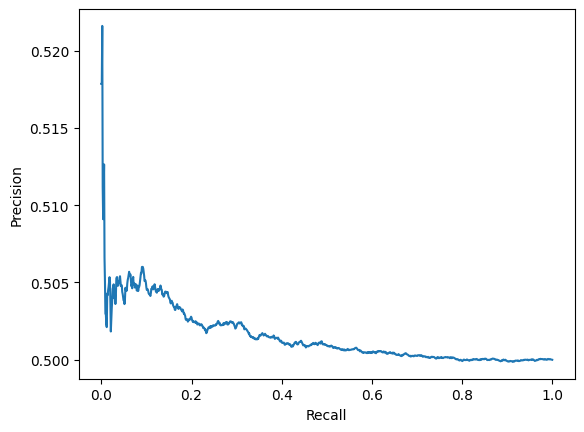

Model Accuracy 0.5008958850628317
FP rate [0.49923846251960463, 0.4989697673547326]
TR rate [0.5010302326452675, 0.5007615374803954]


In [36]:
print(model.summary)
import matplotlib.pyplot as plt
pr = model.summary.pr.toPandas()
plt.plot(pr['recall'],pr['precision'])
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.show()
print("Model Accuracy",model.summary.accuracy)
print("FP rate",model.summary.falsePositiveRateByLabel)
print("TR rate",model.summary.truePositiveRateByLabel)

In [38]:
pr = predict_test.toPandas()
TruePositive =0
FalsePositive=0
TrueNegative=0
FalseNegative=0
Postive=1.0
Negative=0.0
pos=0
Neg=0

print("Total",len(pr["Survived"])) # Changed 'Outcome' to 'Survived'
for lbl in range(len(pr["Survived"])):
  if  pr["prediction"][lbl]==Postive:
    pos+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]: # Changed 'Outcome' to 'Survived'
      TruePositive+=1
    else:
      FalsePositive+=1
  if  pr["prediction"][lbl]==Negative:
    Neg+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]: # Changed 'Outcome' to 'Survived'
      TrueNegative+=1
    else:
      FalseNegative+=1
#print("Total Positive & Negative predicted,  diabetes: ",pos,",Non Diabetes",Neg)
print("TruePostive",TruePositive,"FalsePostive",FalsePositive)
print("TrueNegative",TrueNegative,"FalseNegative",FalseNegative)

Total 199756
TruePostive 49747 FalsePostive 50068
TrueNegative 49667 FalseNegative 50274


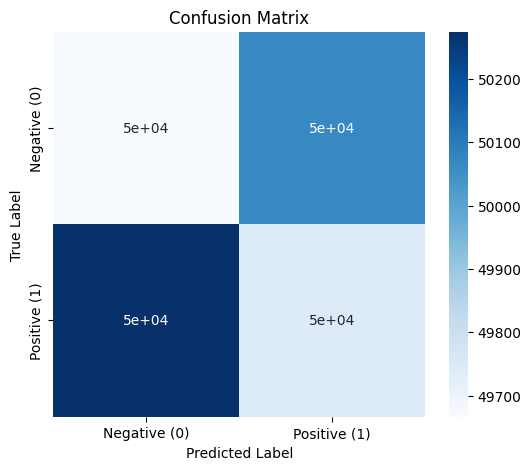

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Import numpy

TN = TrueNegative
FP = FalsePositive
FN = FalseNegative
TP = TruePositive
conf_matrix = np.array([[TN, FP],
                        [FN, TP]])
labels = ["Negative (0)", "Positive (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True,  cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [41]:
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")

Precision: 0.4984
Recall:    0.4974
F1-score:  0.4979
